# Column Info

    Data fields
    Most of the fields are self-explanatory. The following are descriptions for those that aren't.

    Id - an Id that represents a (Store, Date) duple within the test set

    Store - a unique Id for each store

    Sales - the turnover for any given day (this is what you are predicting)

    Customers - the number of customers on a given day

    Open - an indicator for whether the store was open: 0 = closed, 1 = open

    StateHoliday - indicates a state holiday. Normally all stores, with few exceptions, are closed on state holidays. Note that all schools are closed on public holidays and weekends. a = public holiday, b = Easter holiday, c = Christmas, 0 = None

    SchoolHoliday - indicates if the (Store, Date) was affected by the closure of public schools

    StoreType - differentiates between 4 different store models: a, b, c, d

    Assortment - describes an assortment level: a = basic, b = extra, c = extended

    CompetitionDistance - distance in meters to the nearest competitor store

    CompetitionOpenSince[Month/Year] - gives the approximate year and month of the time the nearest competitor was opened

    Promo - indicates whether a store is running a promo on that day

    Promo2 - Promo2 is a continuing and consecutive promotion for some stores: 0 = store is not participating, 1 = store is participating

    Promo2Since[Year/Week] - describes the year and calendar week when the store started participating in Promo2

    PromoInterval - describes the consecutive intervals Promo2 is started, naming the months the promotion is started anew. E.g. "Feb,May,Aug,Nov" means each round starts in February, May, August, November of any given year for that store

# Module & Data Loading

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [62]:
import kagglehub
path = kagglehub.dataset_download("pratyushakar/rossmann-store-sales")

Using Colab cache for faster access to the 'rossmann-store-sales' dataset.


In [63]:
import os
os.listdir(path)

['store.csv', 'train.csv', 'test.csv']

In [64]:
df=pd.read_csv(path+'/train.csv')
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [65]:
stores=pd.read_csv(path+'/store.csv')
stores.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN




---



# Data Cleaning

## Null Values

In [66]:
df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0


## Duplicated

In [67]:
df.duplicated().sum()

np.int64(0)

## Data Types

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [69]:
df['Date']=pd.to_datetime(df['Date'])

In [70]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


## Outliers

In [71]:
df.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846061824,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01




---

# EDA

### Feature Engineering Maybe

**Extracting Date Values**

In [72]:
df['Day_name'] = df['Date'].dt.day_name()

In [73]:
df['Month_name'] = df['Date'].dt.month_name()
df['Month'] = df['Date'].dt.month
df['Year']= df['Date'].dt.year

**Holiday Standardization**

In [75]:
df['StateHoliday'].unique()

array(['0', 'a', 'b', 'c', 0], dtype=object)

In [76]:
df['StateHoliday']=df['StateHoliday'].map({0:0, '0':0,'a':1,'b':1,'c':1})

In [77]:
df['StateHoliday'].unique()

array([0, 1])

## Sales By Day

### Plotting Day Data

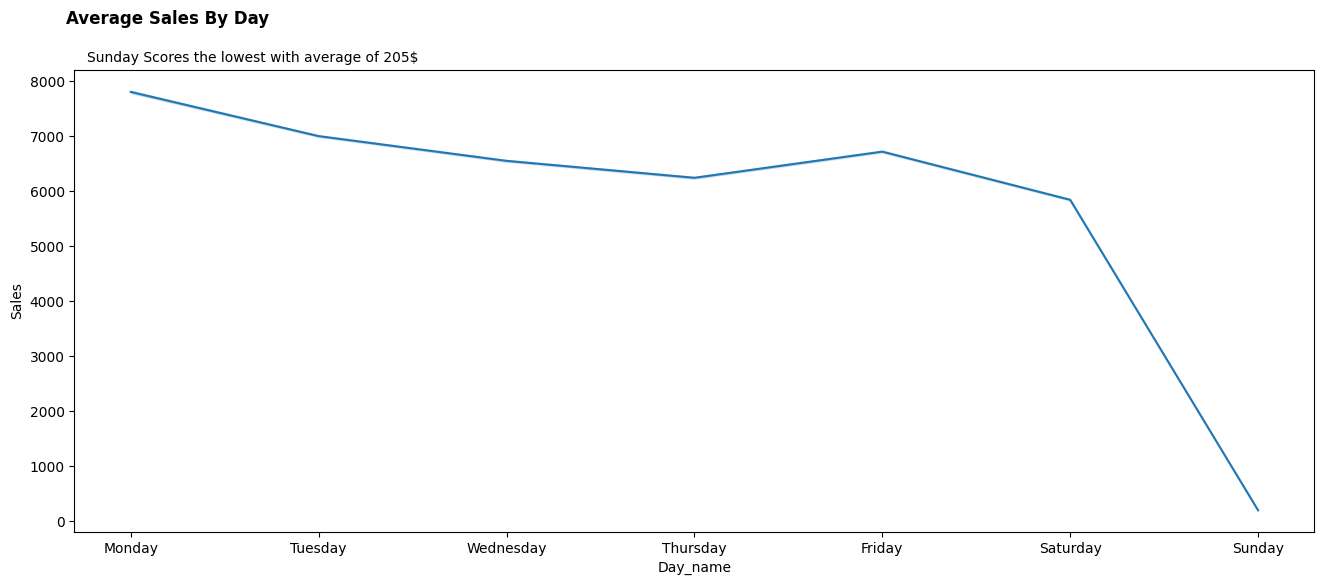

In [37]:
plt.figure(figsize=(16,6))
sns.lineplot(data=df.sort_values(by='DayOfWeek'),x='Day_name',y='Sales')
plt.suptitle('Average Sales By Day', fontweight='bold', x=0.12, fontsize=12,ha='left')
plt.title('Sunday Scores the lowest with average of 205$', x=0.01, fontsize=10,ha='left')
plt.show()

**Context: Rossmann is a German drugstore chain. In Germany, stores are legally required to close on Sundays**

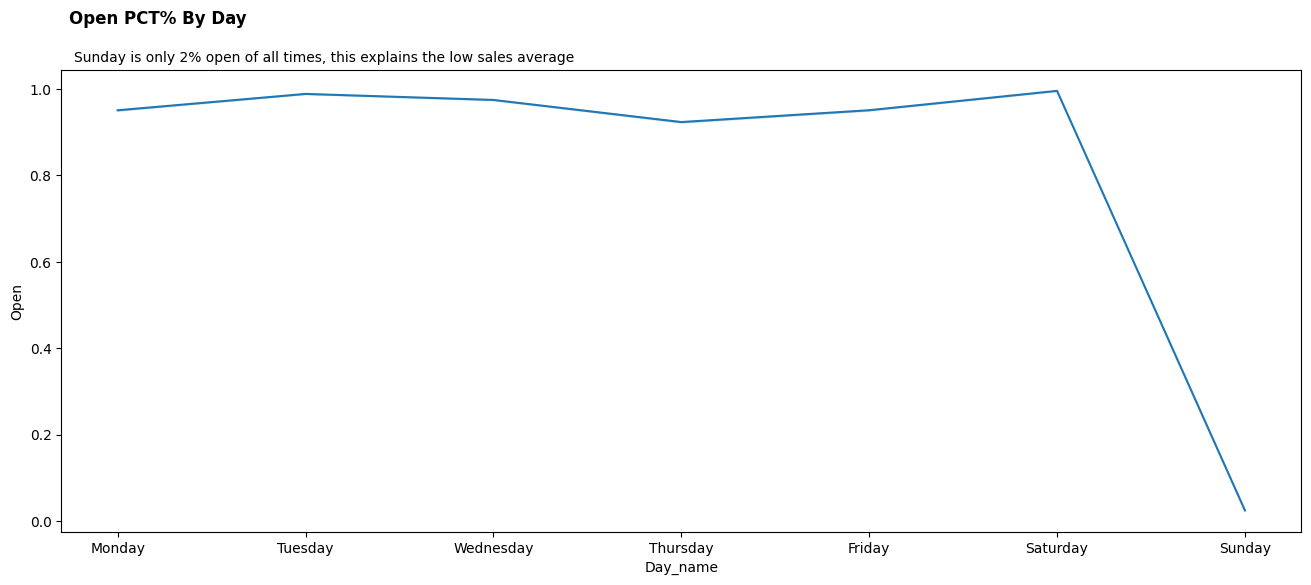

In [40]:
plt.figure(figsize=(16,6))
sns.lineplot(data=df.sort_values(by='DayOfWeek'),x='Day_name',y='Open')
plt.suptitle('Open PCT% By Day', fontweight='bold', x=0.13, fontsize=12,ha='left')
plt.title('Sunday is only 2% open of all times, this explains the low sales average', x=0.01, fontsize=10,ha='left')
plt.show()

## Ghost Store

**Open But 0 Sales Stores**

In [79]:
ghost = df[(df['Open']==1) & (df['Sales']==0)]
ghost.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Day_name,Month_name,Month,Year
86825,971,5,2015-05-15,0,0,1,0,0,1,Friday,May,5,2015
142278,674,4,2015-03-26,0,0,1,0,0,0,Thursday,March,3,2015
196938,699,4,2015-02-05,0,0,1,1,0,0,Thursday,February,2,2015
322053,708,3,2014-10-01,0,0,1,1,0,0,Wednesday,October,10,2014
330176,357,1,2014-09-22,0,0,1,0,0,0,Monday,September,9,2014


**These are likely data errors (server outages, inventory audits) or "closed for refurbishment" days that weren't logged correctly.**

In [85]:
clean_df = df[(df['Open']==0) | (df['Sales']>0)]
clean_df.sample(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Day_name,Month_name,Month,Year
4418,1074,2,2015-07-28,7110,585,1,1,0,1,Tuesday,July,7,2015
128725,501,2,2015-04-07,4694,571,1,0,0,1,Tuesday,April,4,2015
554839,355,3,2014-02-19,8199,979,1,1,0,0,Wednesday,February,2,2014
661388,979,6,2013-11-16,5266,589,1,0,0,0,Saturday,November,11,2013
46142,428,6,2015-06-20,5973,513,1,0,0,0,Saturday,June,6,2015
977881,812,2,2013-02-05,8871,1033,1,1,0,1,Tuesday,February,2,2013
66827,1043,2,2015-06-02,9647,1176,1,1,0,0,Tuesday,June,6,2015
426589,330,6,2014-06-14,4300,437,1,0,0,0,Saturday,June,6,2014
963743,54,7,2013-02-17,0,0,0,0,0,0,Sunday,February,2,2013
224571,457,7,2015-01-11,0,0,0,0,0,0,Sunday,January,1,2015


In [91]:
print("Full Dataset: ", df.shape[0])
print("Ghost Stores: ", ghost.shape[0])
print("After Cleaning: ", clean_df.shape[0])

Full Dataset:  1017209
Ghost Stores:  54
After Cleaning:  1017155


## Promo Lift

In [96]:
promo = clean_df.groupby('Promo')['Sales'].agg(['mean','min','median','max','count','std']).reset_index()
print(promo)

   Promo         mean  min  median    max   count          std
0      0  4406.281930    0  4622.0  41551  629096  3442.392390
1      1  7991.584491    0  7554.0  38722  388059  3418.612585


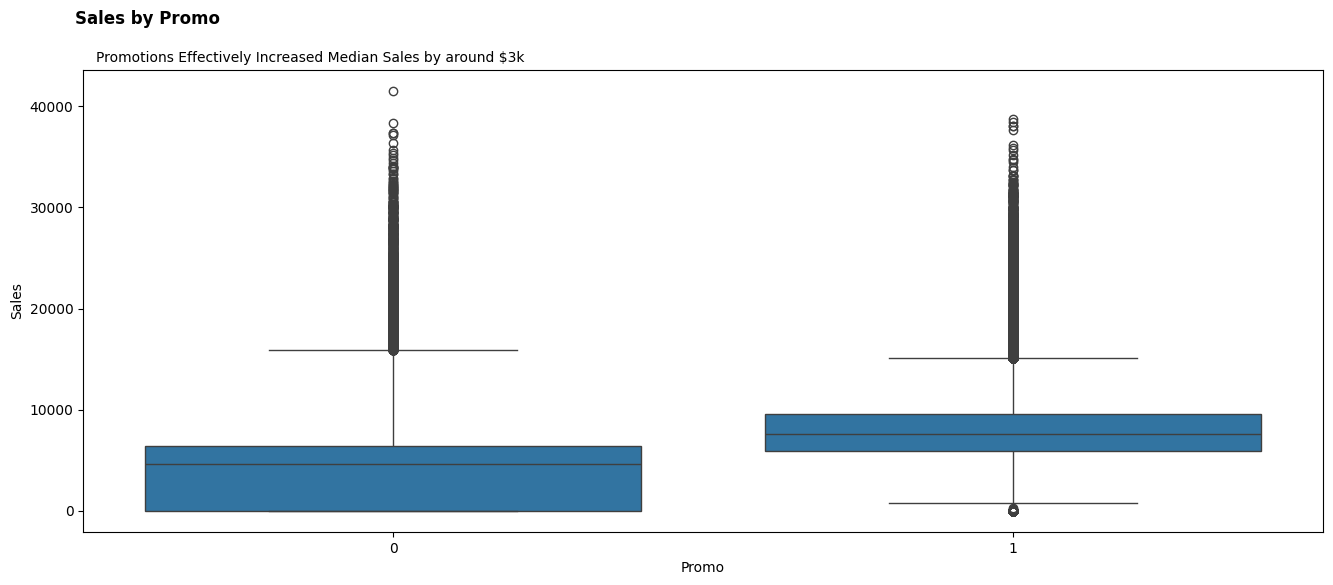

In [97]:
plt.figure(figsize=(16,6))
sns.boxplot(data=clean_df,x='Promo',y='Sales')
plt.suptitle('Sales by Promo', fontweight='bold', x=0.12, fontsize=12, ha='left')
plt.title('Promotions Effectively Increased Median Sales by around $3k', x=0.01, fontsize=10,ha='left')
plt.show()

**Promotions Effectively Increased Median Sales by around $3000**

----
# The Forecast

In [105]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

## Feature Engineering:

**Removing Object Data For ML**

In [107]:
ml_df = clean_df.copy()
ml_df.drop(columns=['Month_name','Day_name'], inplace=True)
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1017155 entries, 0 to 1017208
Data columns (total 11 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017155 non-null  int64         
 1   DayOfWeek      1017155 non-null  int64         
 2   Date           1017155 non-null  datetime64[ns]
 3   Sales          1017155 non-null  int64         
 4   Customers      1017155 non-null  int64         
 5   Open           1017155 non-null  int64         
 6   Promo          1017155 non-null  int64         
 7   StateHoliday   1017155 non-null  int64         
 8   SchoolHoliday  1017155 non-null  int64         
 9   Month          1017155 non-null  int32         
 10  Year           1017155 non-null  int32         
dtypes: datetime64[ns](1), int32(2), int64(8)
memory usage: 85.4 MB


**Selecting Store**

In [137]:
ml_df=ml_df[ml_df['Store']==1]

**Train, Test Datasets**

In [138]:
train_df = ml_df[ml_df['Date'] < '2015-06-14']
test_df = ml_df[ml_df['Date'] > '2015-06-14']

X_train = train_df.drop(columns=['Date','Sales','Customers'])
y_train = train_df['Sales']

X_test = test_df.drop(columns=['Date','Sales','Customers'])
y_test = test_df['Sales']

## Modeling

**Fitting**

In [139]:
rf=RandomForestRegressor()
rf.fit(X_train,y_train)

RandomForestRegressor()

**Predicting**

In [140]:
y_pred= rf.predict(X_test)

**Scoring**

In [143]:
print(f"R2 Score: {r2_score(y_test,y_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test,y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y_test,y_pred)}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test,y_pred))}")

R2 Score: 0.9283309236984885
Mean Absolute Error: 306.07619056829714
Mean Squared Error: 187872.83670325752
Root Mean Squared Error: 433.4430028311191


**Comaprison**

In [144]:
test_df['Predicted_Sales']=y_pred

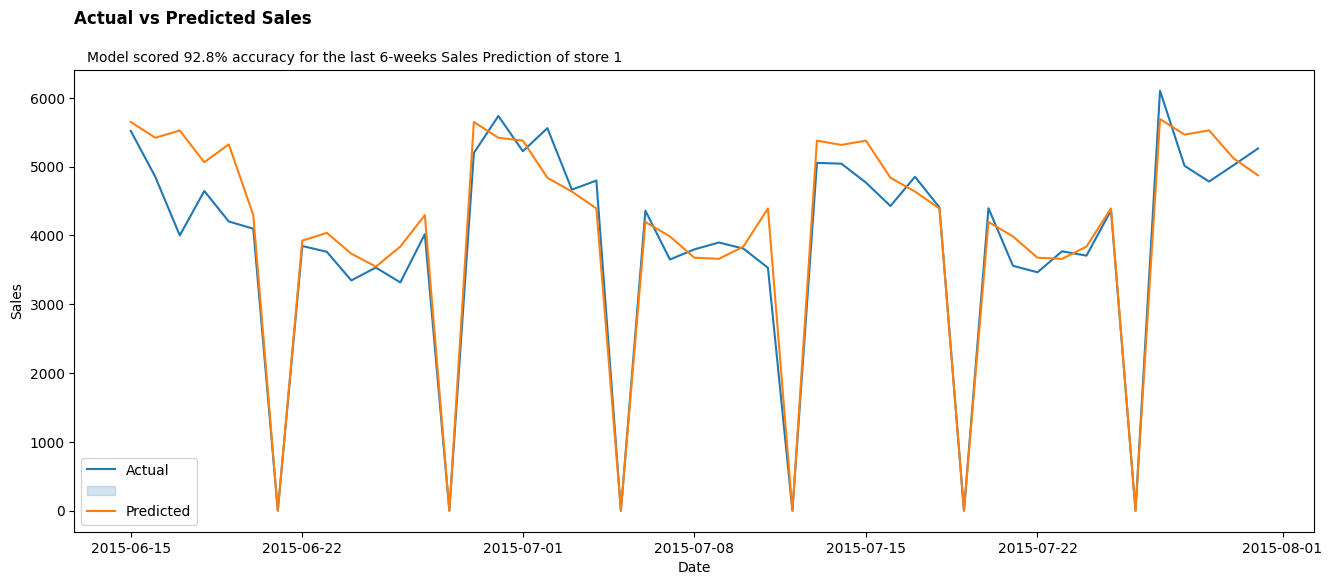

In [145]:
plt.figure(figsize=(16,6))
sns.lineplot(data=test_df,x='Date',y='Sales')
sns.lineplot(data=test_df,x='Date',y='Predicted_Sales')
plt.suptitle('Actual vs Predicted Sales', fontweight='bold', x=0.125, fontsize=12, ha='left')
plt.title('Model scored 92.8% accuracy for the last 6-weeks Sales Prediction of store 1', x=0.01, fontsize=10, ha='left')
plt.legend(['Actual','','Predicted'])
plt.show()
